# Part 1 : Numerical Columns — Statistical Measures

### The full statistics toolkit

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/titanic.csv')

In [6]:
col = df['Age'].dropna()
print(f"count : {col.count():.2f}")
print(f"mean : {col.mean():.2f}")
print(f"median : {col.median():.2f}")
print(f"mode : {col.mode()[0]:.2f}")
print(f"25th percentile : {col.quantile(0.25):.2f}")
print(f"75th percentile : {col.quantile(0.75):.2f}")
print(f"IQR : {col.quantile(0.75) - col.quantile(0.25):.2f}")
print(f"standard deviation : {col.std():.2f}")
print(f"varaince : {col.var():.2f}")
print(f"min : {col.min():.2f}")
print(f"max : {col.max():.2f}")
print(f"range : {col.min() - col.max():.2f}")
print(f"skewness : {col.skew():.4f}")
print(f"kurtosis : {col.kurtosis():.4f}")

count : 714.00
mean : 29.70
median : 28.00
mode : 24.00
25th percentile : 20.12
75th percentile : 38.00
IQR : 17.88
standard deviation : 14.53
varaince : 211.02
min : 0.42
max : 80.00
range : -79.58
skewness : 0.3891
kurtosis : 0.1783


## Understanding Skewness and Kurtosis — The Two Most Misunderstood Metrics

These two tell you the **shape of your distribution** — information that 
mean and median alone cannot reveal.

---

### Skewness — Measuring Asymmetry

Skewness measures how asymmetric a distribution is around its mean.

| Skewness Value | Meaning |
|----------------|---------|
| `= 0` | Perfectly symmetric (normal distribution) |
| `> 0` (Positive) | Tail is on the **right** — mean > median |
| `< 0` (Negative) | Tail is on the **left** — mean < median |

> **Rule of thumb:**
> - `|skewness| < 0.5` → fairly symmetric
> - `0.5 < |skewness| < 1` → moderately skewed
> - `|skewness| > 1` → highly skewed

**Real-world example:**
Salary data is almost always **positively skewed**. Most employees earn 
₹30,000–₹80,000, but a few executives earn ₹50 lakhs — pulling the mean 
far above the median. When **mean > median**, you have right skew.

```python
col.skew()   # positive value → right skewed
```

---

### Kurtosis — Measuring Peakedness

Kurtosis measures how **peaked or flat** a distribution is compared to a 
normal distribution (baseline = `0` in pandas).

| Kurtosis Value | Type | Meaning |
|----------------|------|---------|
| `= 0` | Mesokurtic | Normal distribution |
| `> 0` (Positive) | **Leptokurtic** | Sharper peak, heavier tails |
| `< 0` (Negative) | **Platykurtic** | Flatter peak, lighter tails |

**Real-world example:**
Stock market daily returns have **high positive kurtosis** — most days 
are near zero change, but occasionally there are extreme crashes or surges 
(heavy tails). This is why normal distribution underestimates financial risk.


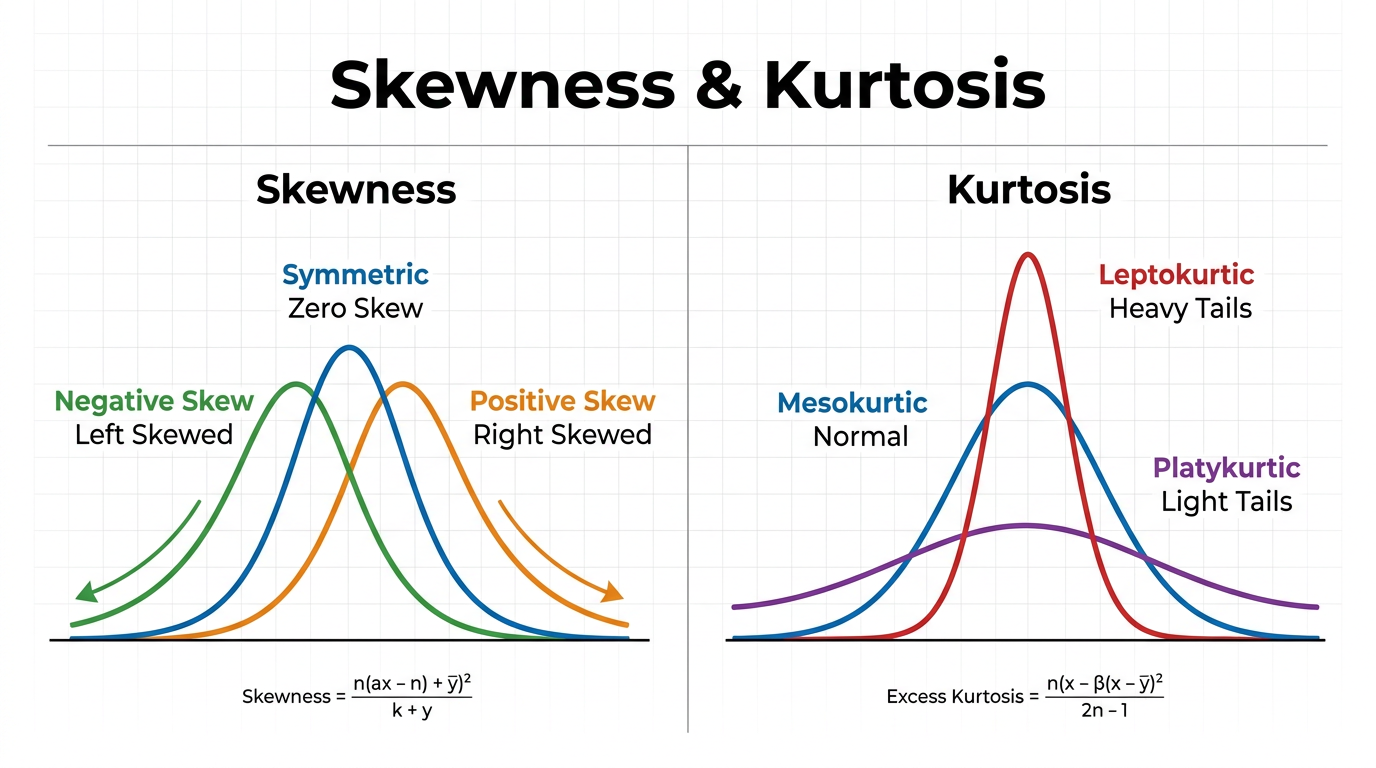

# Part 2 : All Plots for Numerical Columns

## Plot 1 - Histogram
The histogram is the most fundamental plot in EDA. 
It divides values into bins and shows how many values fall in each bin
— revealing the shape, center, and spread of the distribution at once.

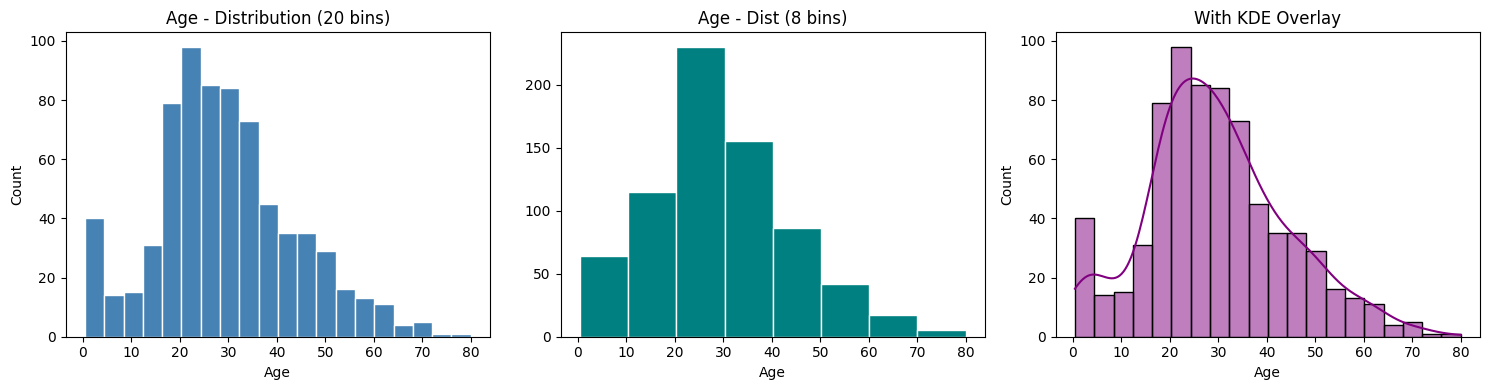

sqrt rule: 26 bins
sturges:   10 bins


In [7]:
import matplotlib.pyplot as plt , seaborn as sns

fig , axes = plt.subplots(1 , 3 , figsize = (15 , 4))

# basic histogram
axes[0].hist(df['Age'].dropna() , bins = 20 , color = 'steelblue' , edgecolor = 'white')
axes[0].set_title('Age - Distribution (20 bins)')
axes[0].set_xlabel('Age') ; axes[0].set_ylabel('Count')

# lesser bins
axes[1].hist(df['Age'].dropna() , bins = 8 , color = 'teal' , edgecolor = 'white')
axes[1].set_title('Age - Dist (8 bins)')
axes[1].set_xlabel('Age')

# seaborn version 
sns.histplot(df['Age'].dropna() , bins = 20 , kde = True , ax = axes[2] , color = 'purple')
axes[2].set_title('With KDE Overlay')

plt.tight_layout()
plt.show()

# bins rule of thumb : sqrt(n) for small data , sturges : 1 + log2(n) for large
import math
n = df['Age'].dropna().count()
print(f"sqrt rule: {int(math.sqrt(n))} bins")
print(f"sturges:   {int(1 + math.log2(n))} bins")

## Plot 2 — KDE (Kernel Density Estimate)
A KDE is a smoothed histogram. Instead of bars, it draws a continuous curve showing the probability density.
It's especially good for comparing distributions overlaid on the same chart.

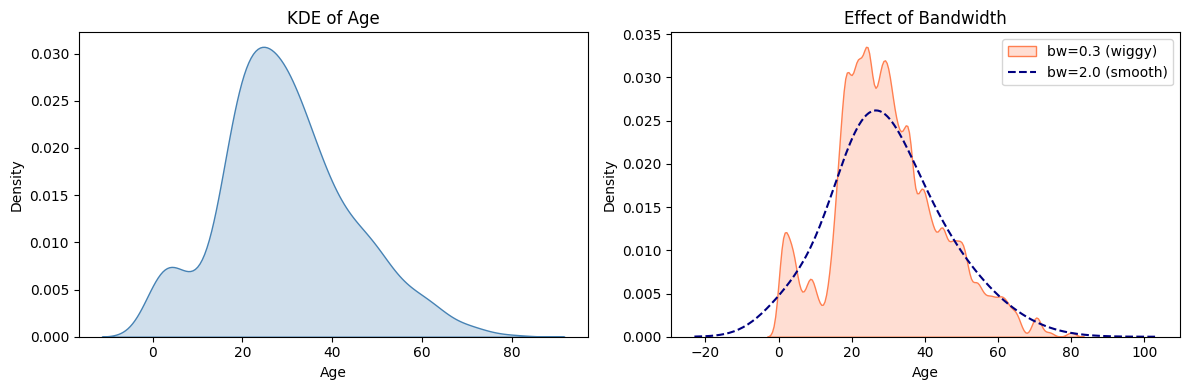

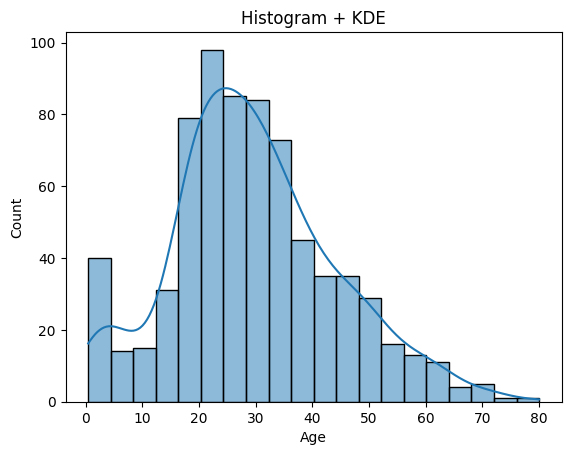

In [13]:
fig, axes = plt.subplots(1 , 2 , figsize = (12, 4))

# KDE 
sns.kdeplot(df['Age'].dropna(), ax = axes[0], fill = True, color = 'steelblue')
axes[0].set_title('KDE of Age')
axes[0].set_xlabel('Age')

# KDE with bandwidth control (bandwidth = how smooth)
sns.kdeplot(df['Age'].dropna() , ax = axes[1] , bw_adjust = 0.3 , fill = True ,
            color = 'coral', label = 'bw=0.3 (wiggy)')
sns.kdeplot(df['Age'].dropna(), ax = axes[1], bw_adjust = 2.0, fill = False,
            color = 'navy', linestyle = '--', label = 'bw=2.0 (smooth)')
axes[1].legend()
axes[1].set_title('Effect of Bandwidth')

plt.tight_layout()
plt.show()

#  histogram + KDE together:
sns.histplot(df['Age'].dropna(), kde = True, bins = 20)
plt.title('Histogram + KDE')
plt.show()

## Plot 3 — Boxplot
The boxplot compresses a distribution into 5 numbers: minimum, Q1, median, Q3, maximum. Outliers appear as individual dots.

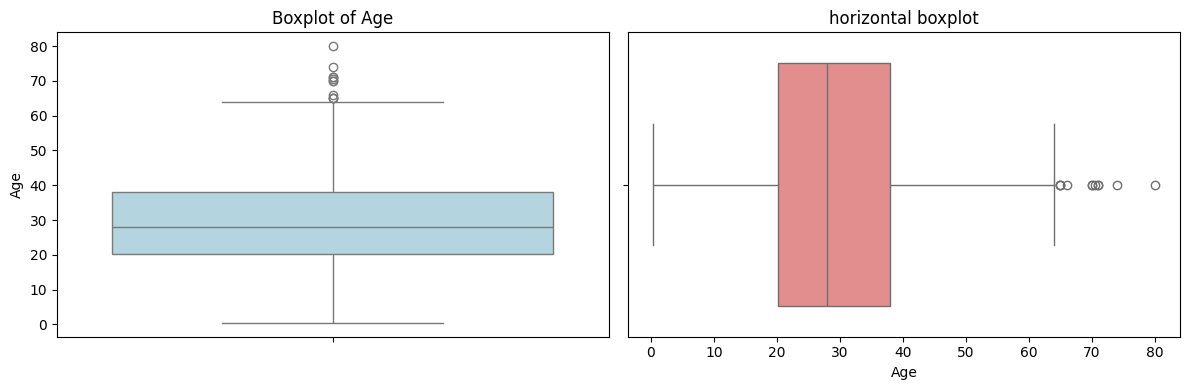

In [16]:
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

# basic boxplot
sns.boxplot(y = df['Age'].dropna() , ax = axes[0] , color = 'lightblue')
axes[0].set_title('Boxplot of Age')

# horizontal boxplot
sns.boxplot(x = df['Age'].dropna() , ax = axes[1] , color = 'lightcoral')
axes[1].set_title('horizontal boxplot')

plt.tight_layout()
plt.show()

# Reading a boxplot:
# The BOX spans Q1 to Q3 (the middle 50% of data = IQR)
# The LINE inside the box = median
# The WHISKERS extend to min/max within 1.5×IQR
# Individual DOTS beyond whiskers = outliers

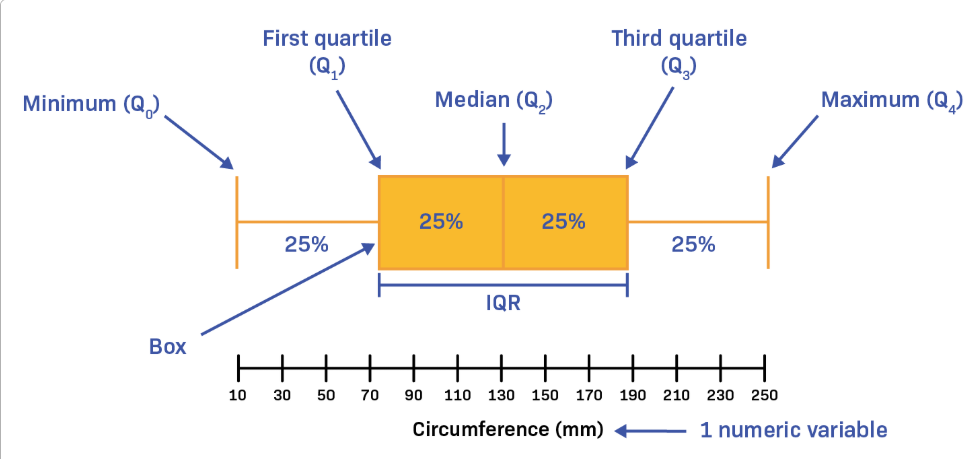

## Plot 4 — Violin Plot
A violin plot combines the boxplot's summary statistics with the KDE's shape information. The width of the "violin" at any point represents how many data points have that value — wider = more data there.

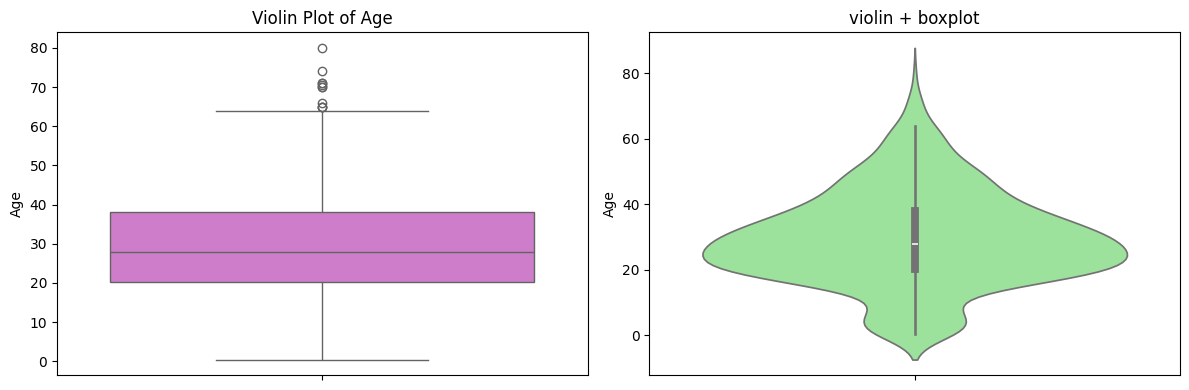

In [18]:
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

# violin plot
sns.boxplot(y = df['Age'].dropna() , ax = axes[0] , color = 'orchid' )
axes[0].set_title('Violin Plot of Age')

# violin with inner boxplot
sns.violinplot(y = df['Age'].dropna() , ax = axes[1] , inner = 'box' , color = 'lightgreen' )
axes[1].set_title("violin + boxplot")


plt.tight_layout()
plt.show()

# When to use violin vs boxplot:
# Boxplot    -> Quick comparison, outlier-focused, presentations
# Violin    -> When you care about the shape (bimodal? skewed?)
#             especially when comparing groups side by side

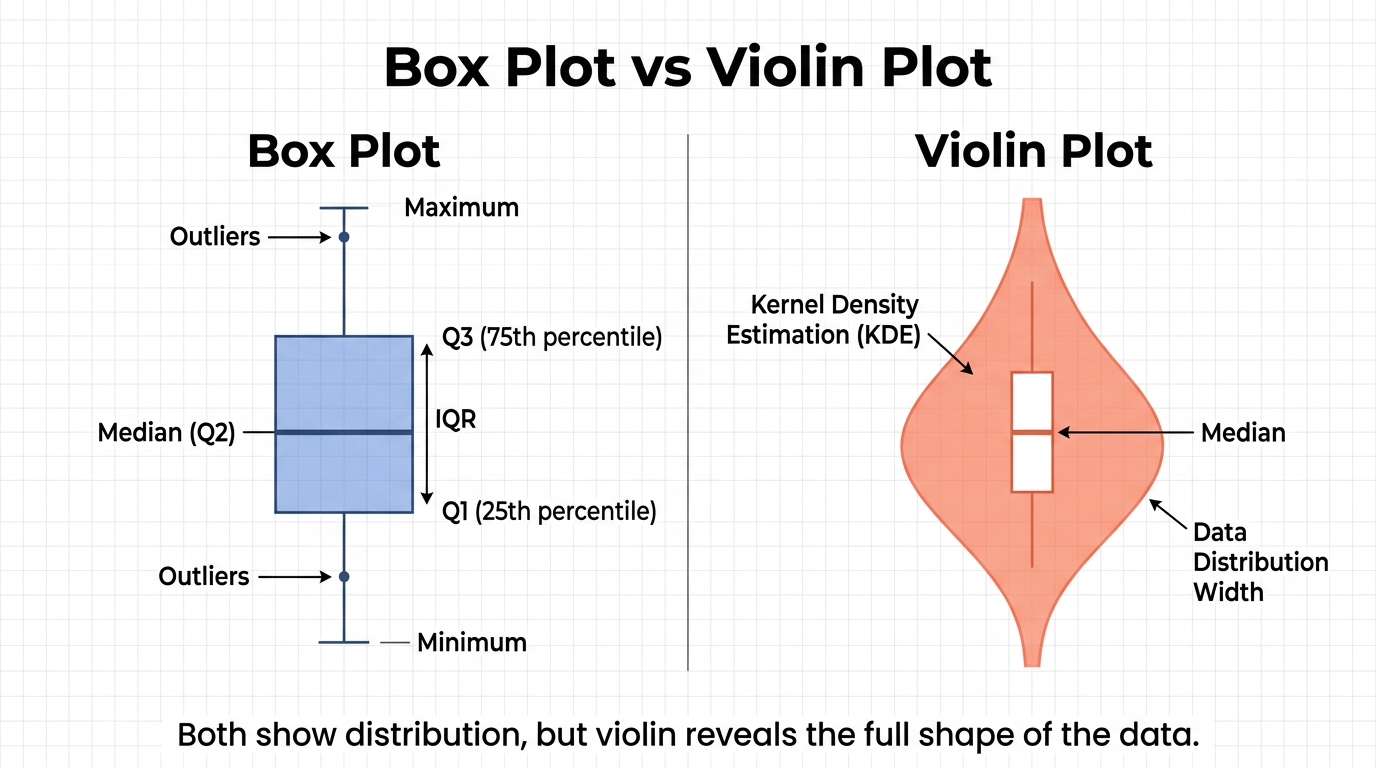

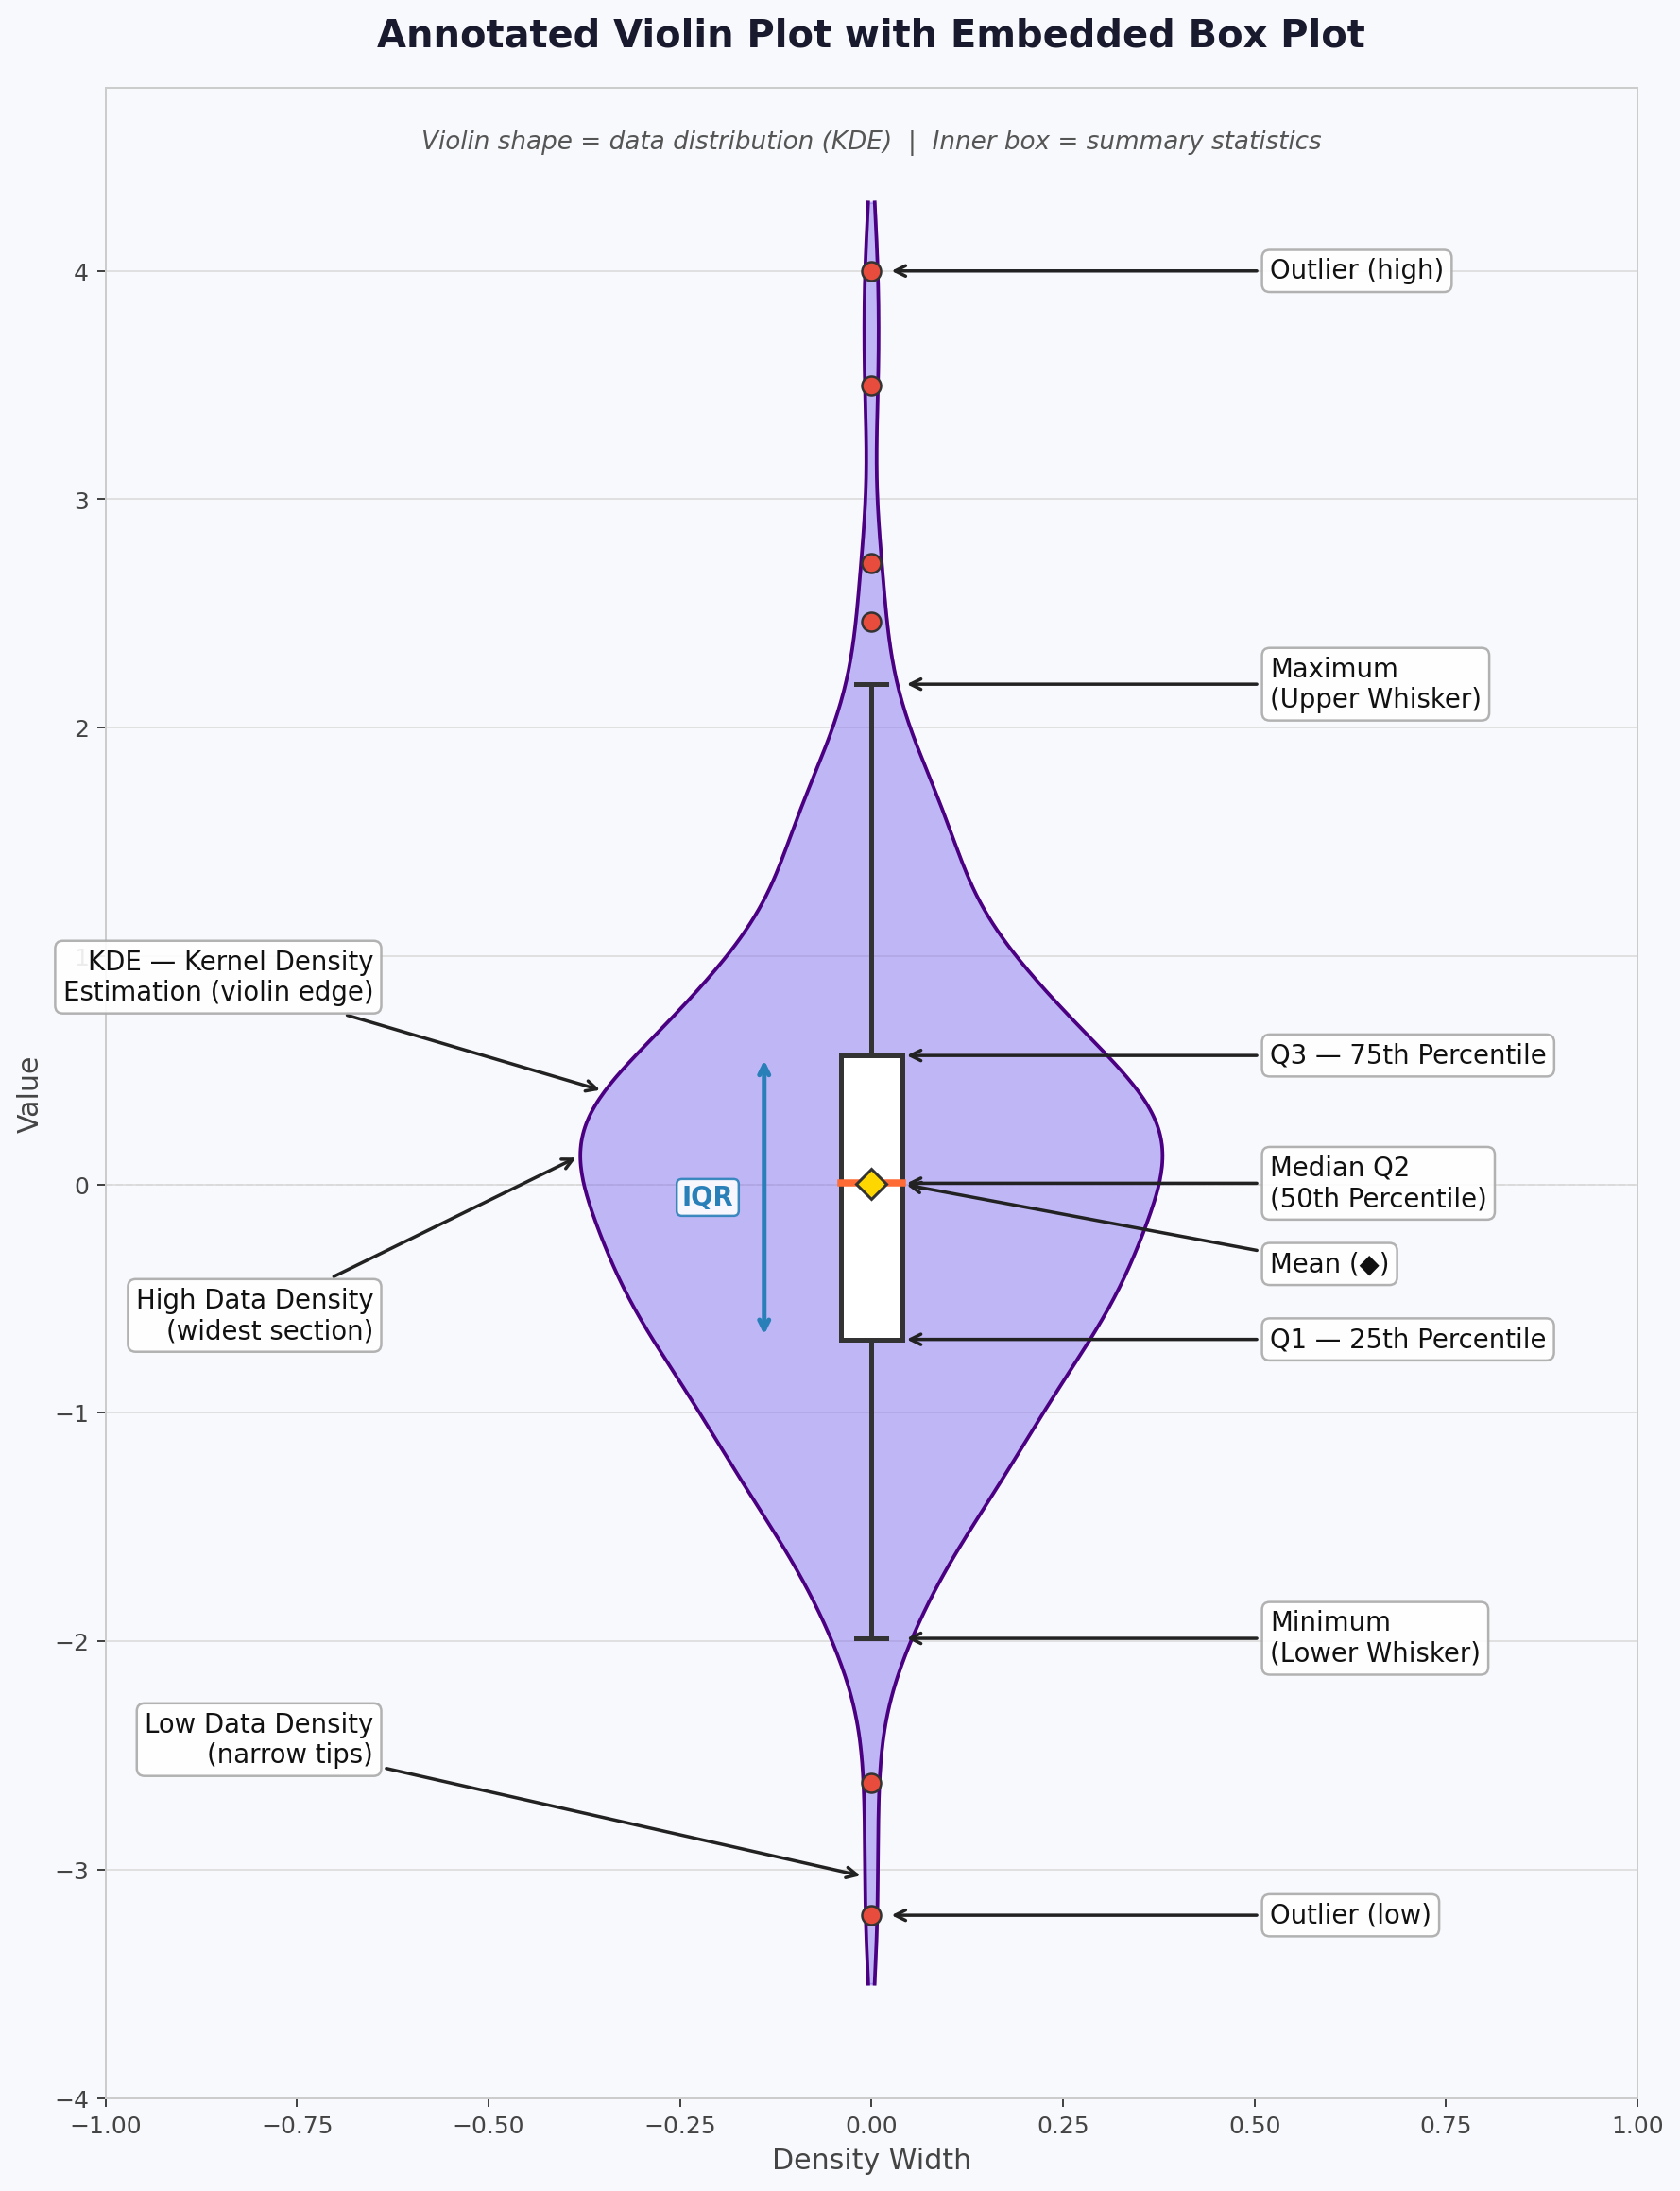

# Part 3: Categorical Columns - Statistical Measures

In [23]:
# value counts - the foundation of categorical canalysis  
print(df['Sex'].value_counts())

print('--- ' * 20)

# with percentages
print(df['Sex'].value_counts(normalize = True).round(3) * 100)

print('--- ' * 20)

# all key stats for a categorical column 
col = df['Embarked']

print(f"unique values  : {col.nunique()}")       # how many categories
print(f"all categories : {col.unique()}")         # what are they
print(f"mode (top cat) : {col.mode()[0]}")        # most common category
print(f"missing        : {col.isnull().sum()}") 


print('--- ' * 20)

freq_table = pd.DataFrame({
    'count': col.value_counts(),
    'pct':   col.value_counts(normalize=True).mul(100).round(1)
})
print(freq_table)

Sex
male      577
female    314
Name: count, dtype: int64
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
Sex
male      64.8
female    35.2
Name: proportion, dtype: float64
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
unique values  : 3
all categories : ['S' 'C' 'Q' nan]
mode (top cat) : S
missing        : 2
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
          count   pct
Embarked             
S           644  72.4
C           168  18.9
Q            77   8.7


# Part 4: All Plots for Categorical Columns

## Plot 5 - Count Plot (Bar Chart for Categories)

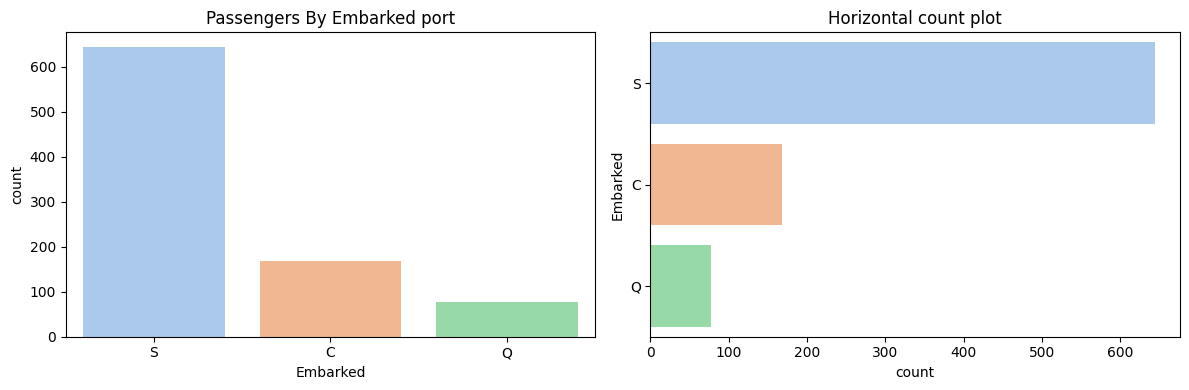

In [26]:
# basic couhnt plot
fig , axes = plt.subplots( 1 , 2 , figsize = (12 , 4))
sns.countplot(x = 'Embarked' , hue = 'Embarked' , data = df , ax = axes[0] , palette= 'pastel' , 
             legend = False , order = df['Embarked'].value_counts().index)

axes[0].set_title('Passengers By Embarked port')

# hirizontal better for categorical 
sns.countplot(y = 'Embarked' , hue = 'Embarked' , data = df , ax = axes[1] , palette = 'pastel' , 
             legend = False , order = df['Embarked'].value_counts().index)
axes[1].set_title('Horizontal count plot')

plt.tight_layout()
plt.show()

# Always sort by frequency
#unsorted bars make comparsion harder 

## Plot 6 - Pie Chart

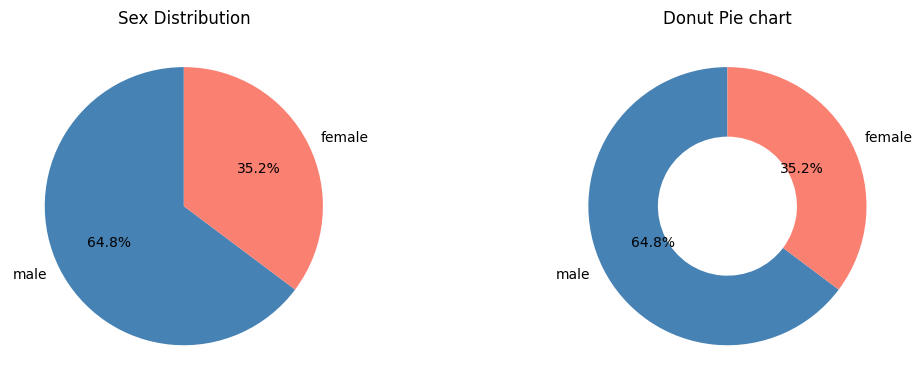

In [33]:
# pie chart - for prapotional composition
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

# pie chart
sex_counts = df['Sex'].value_counts()
axes[0].pie(sex_counts.values,
            labels = sex_counts.index,
            autopct = '%1.1f%%',
            colors = ['steelblue', 'salmon'],
            startangle = 90)
axes[0].set_title('Sex Distribution')

# donut chart (modern)
axes[1].pie(sex_counts.values,
            labels = sex_counts.index,
            autopct = '%1.1f%%', 
            colors = ['steelblue' , 'salmon'], 
            wedgeprops = {'width' : 0.5},
            startangle = 90)
axes[1].set_title('Donut Pie chart')

plt.tight_layout()
plt.show()

When to use pie vs bar: Use pie only when you have 2–4 categories and want to show proportional composition (what fraction of the whole). For anything with 5+ categories or when comparing multiple groups, use bar. Human eyes are bad at comparing slice sizes — a bar chart is almost always clearer.

###  When to Use Which Plot

| Plot | Use When... | Insight It Gives |
|------|------------|-----------------|
| **Histogram** | First look at any numerical column | Shape, skew, modality, spread |
| **KDE** | Smooth shape, overlaying 2+ groups | Continuous distribution, overlap |
| **Boxplot** | Quick summary + outlier detection | Median, IQR, outliers at a glance |
| **Violin** | When distribution shape matters | Full shape + summary in one view |
| **Count Plot** | Any categorical column, always | Frequency, dominance, imbalance |
| **Pie / Donut** | 2–4 categories, part-of-whole story | Proportional composition |

---

> **Quick Rule:**
> - Numerical column → start with **Histogram**
> - Comparing groups → use **KDE** or **Violin**
> - Spotting outliers → use **Boxplot**
> - Categorical column → always start with **Count Plot**
> - Showing proportions → **Pie** only when categories ≤ 4

###  Key Insights to Draw from Univariate Analysis

After running univariate analysis on every column, you should be able to 
answer these questions **before touching any model:**

---

| Question | Why It Matters |
|----------|---------------|
| **Is the data skewed?** | If yes -> median better than mean; consider log transform |
| **Are there outliers?** | Boxplot whiskers → apply IQR method treatment |
| **Is a categorical column class-imbalanced?** | Target imbalance -> needs special ML handling (SMOTE, `class_weight`) |
| **Are there only 2 unique values in a numerical column?** | May be a miscoded boolean — fix the dtype |
| **Does the distribution look bimodal?** | May indicate two hidden sub-groups (male/female, old/new users) |
| **Does mode equal the median?** | Sign of a near-symmetric distribution with no outlier influence |

---

>  **Golden Rule:**
> Univariate analysis is not just about plotting —
> it's about making **decisions** for every column before modeling.
> Every insight here directly affects your preprocessing pipeline.

---

>  **Never skip univariate analysis.** A skewed column fed raw into 
> a Linear Regression will silently hurt your model's performance.

# END of notebook 3